C:\Users\suman\AppData\Local\Temp\ipykernel_22696\747505882.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=odor_counts.head(top_n).index, y=odor_counts.head(top_n).values, palette="viridis")


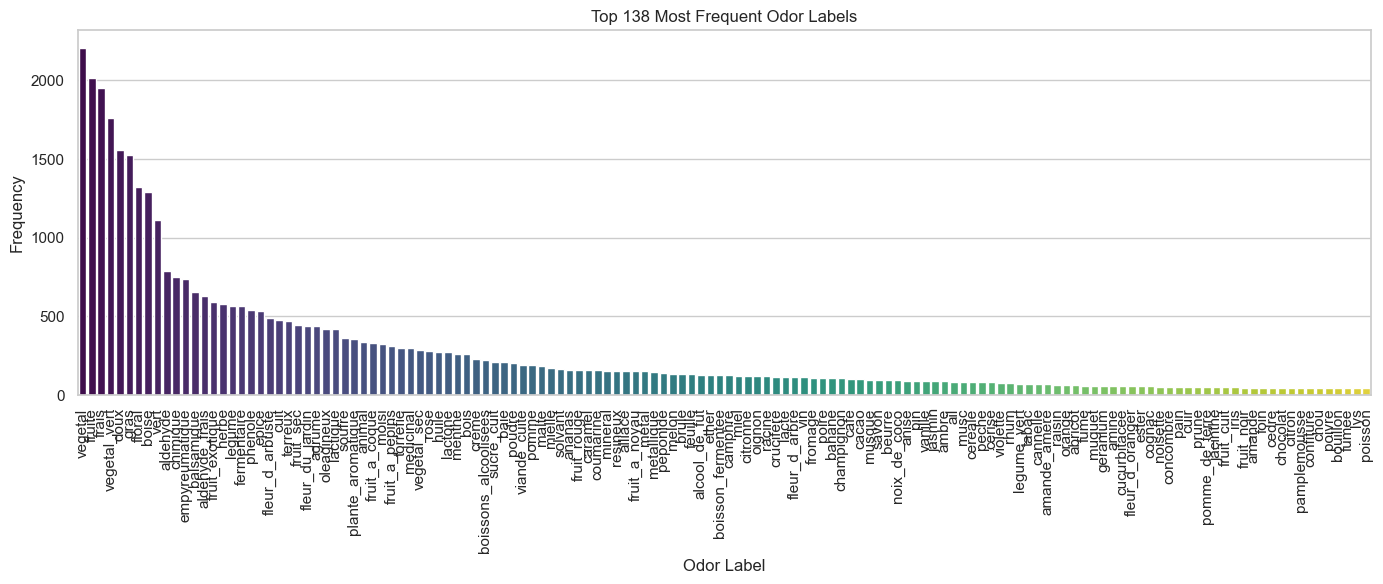

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\data\(Saturated)SoS_Full.csv")

# Exclude identifier and SMILES columns
odor_columns = df.columns[2:]

# Count how many times each odor descriptor appears
odor_counts = df[odor_columns].sum().sort_values(ascending=False)
odor_counts2 = df[odor_columns].sum().sort_values(ascending=True)

# Set Seaborn style
sns.set(style="whitegrid")

# Plot the histogram for top 50 odor labels
plt.figure(figsize=(14, 6))
top_n = 138
sns.barplot(x=odor_counts.head(top_n).index, y=odor_counts.head(top_n).values, palette="viridis")
plt.xticks(rotation=90)
plt.title(f"Top {top_n} Most Frequent Odor Labels")
plt.ylabel("Frequency")
plt.xlabel("Odor Label")
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

# Load your dataset
df = pd.read_csv(r"C:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\data\(Saturated)SoS_Full.csv")

# Extract label columns
odor_labels = df.columns[2:]
odor_df = df[odor_labels]


C:\Users\suman\AppData\Local\Temp\ipykernel_22696\982838082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=odor_counts.index[:50], y=odor_counts.values[:50], palette="mako")


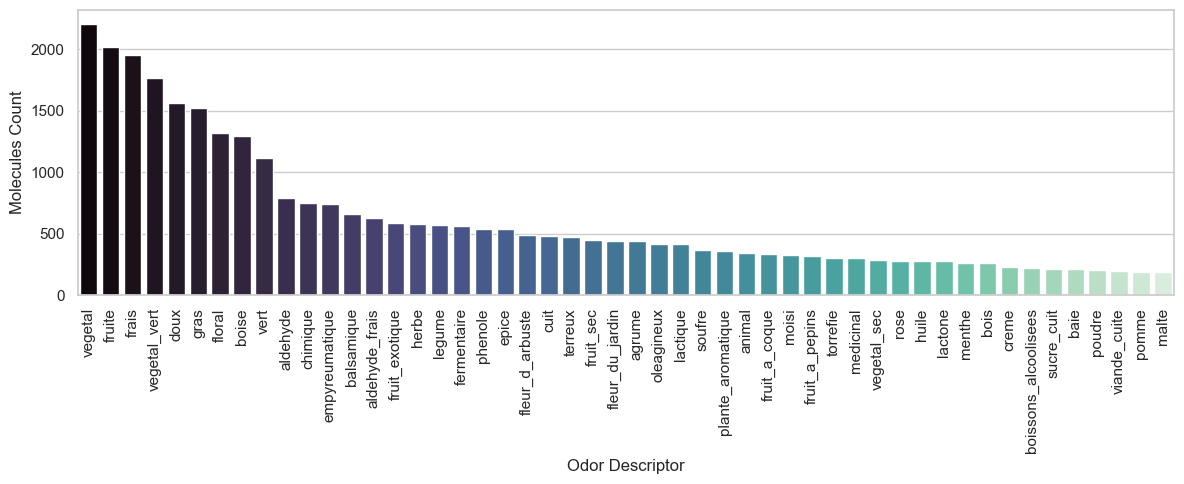

In [3]:
odor_counts = odor_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=odor_counts.index[:50], y=odor_counts.values[:50], palette="mako")
plt.xticks(rotation=90)
plt.ylabel("Molecules Count")
plt.xlabel("Odor Descriptor")
plt.tight_layout()
plt.show()


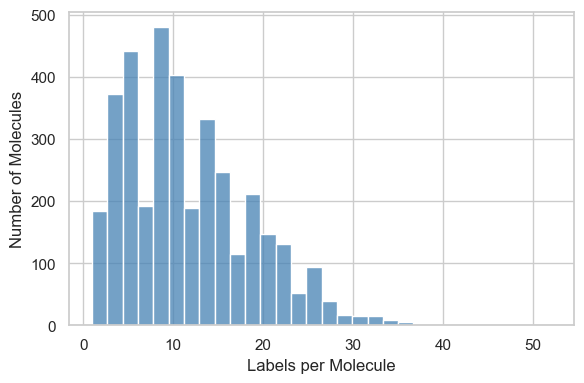

In [4]:
# Assuming `label_density` = number of labels per molecule
label_density = odor_df.sum(axis=1)

plt.figure(figsize=(6, 4))
sns.histplot(label_density, bins=30, kde=False, color="steelblue")
plt.xlabel("Labels per Molecule")
plt.ylabel("Number of Molecules")
plt.tight_layout()
plt.show()



c:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\myenv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:310: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


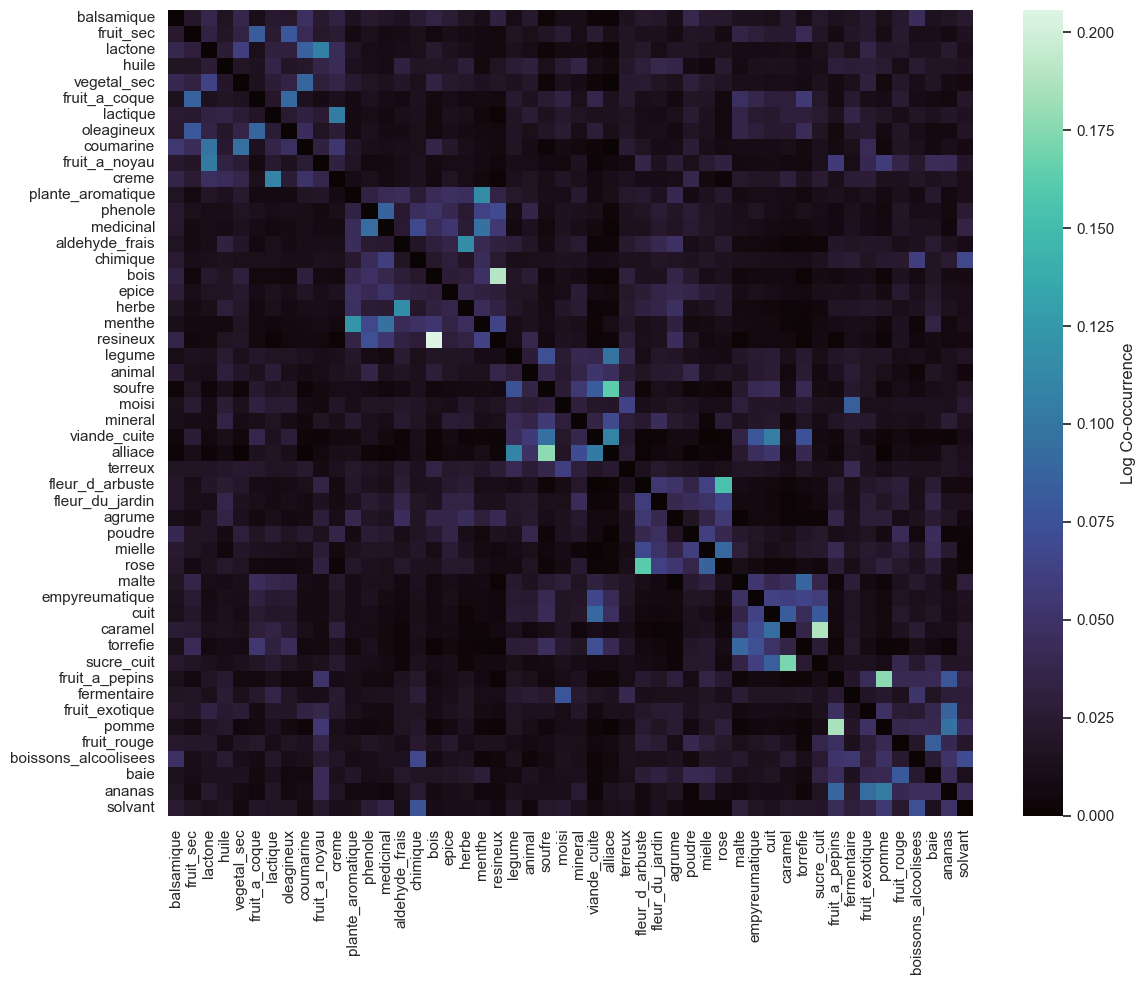

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.cluster import SpectralClustering

# Step 1: Remove top 10 most frequent descriptors
top10 = odor_counts.index[:10]
remaining_labels = [label for label in odor_labels if label not in top10]

# Step 2: Compute frequencies again to get top 50 of remaining
odor_counts_filtered = df[remaining_labels].sum().sort_values(ascending=False)
top50_labels = odor_counts_filtered.index[:50]

# Step 3: Build co-occurrence matrix for top 50
co_mat_50 = np.dot(df[top50_labels].T, df[top50_labels])
np.fill_diagonal(co_mat_50, 0)

# Step 4: Normalize rows and columns
co_mat_norm_50 = normalize(co_mat_50, axis=1, norm='l1')
co_mat_norm_50 = normalize(co_mat_norm_50.T, axis=1, norm='l1')

# Step 5: Spectral clustering to reorder
clustering = SpectralClustering(
    n_clusters=6,  # Feel free to adjust
    affinity='precomputed',
    assign_labels='discretize',
    random_state=42
)
cluster_labels = clustering.fit_predict(co_mat_norm_50)
sorted_idx = np.argsort(cluster_labels)
co_mat_sorted_50 = co_mat_norm_50[sorted_idx, :][:, sorted_idx]
sorted_labels = [top50_labels[i] for i in sorted_idx]

# Step 6: Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    np.log1p(co_mat_sorted_50),  # log1p for better contrast
    cmap="mako",
    xticklabels=sorted_labels,
    yticklabels=sorted_labels,
    cbar_kws={"label": "Log Co-occurrence"}
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import numpy as np

# Read CSV
df = pd.read_csv(r"C:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\data\openPOMData\Mapped_OpenPOM + unmapped_odor.csv")

# Get label columns
odor_labels = df.columns[2:]
odor_df = df[odor_labels]

# Total molecules
total_molecules = len(df)

# Sum per label
label_counts = odor_df.sum(axis=0)

# Compute stats
total_labels = len(label_counts)
max_count = label_counts.max()
min_count_nonzero = label_counts[label_counts > 0].min()
imbalance_ratio = max_count / min_count_nonzero if min_count_nonzero > 0 else np.nan
mean_count = label_counts.mean()
std_dev_count = label_counts.std()

# Print results
print(f"Total Molecules: {total_molecules}")
print(f"Total Labels: {total_labels}")
print(f"Max Count: {max_count}")
print(f"Min Count (non-zero): {min_count_nonzero}")
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")
print(f"Mean: {mean_count:.2f}")
print(f"Std Dev: {std_dev_count:.2f}")


Total Molecules: 4983
Total Labels: 138
Max Count: 1902
Min Count (non-zero): 31
Imbalance Ratio (Max/Min): 61.35
Mean: 176.17
Std Dev: 264.02


Loaded dataset with shape: (4983, 140)
Number of samples: 4983
Number of labels: 138

--- Label Frequency Statistics ---
Min frequency: 1.12%
Max frequency: 53.40%
Mean frequency: 6.51%
Median frequency: 3.15%
Std. dev of frequencies: 9.25%
Most frequent label: fruity (53.40%)
Least frequent label: muguet (1.12%)


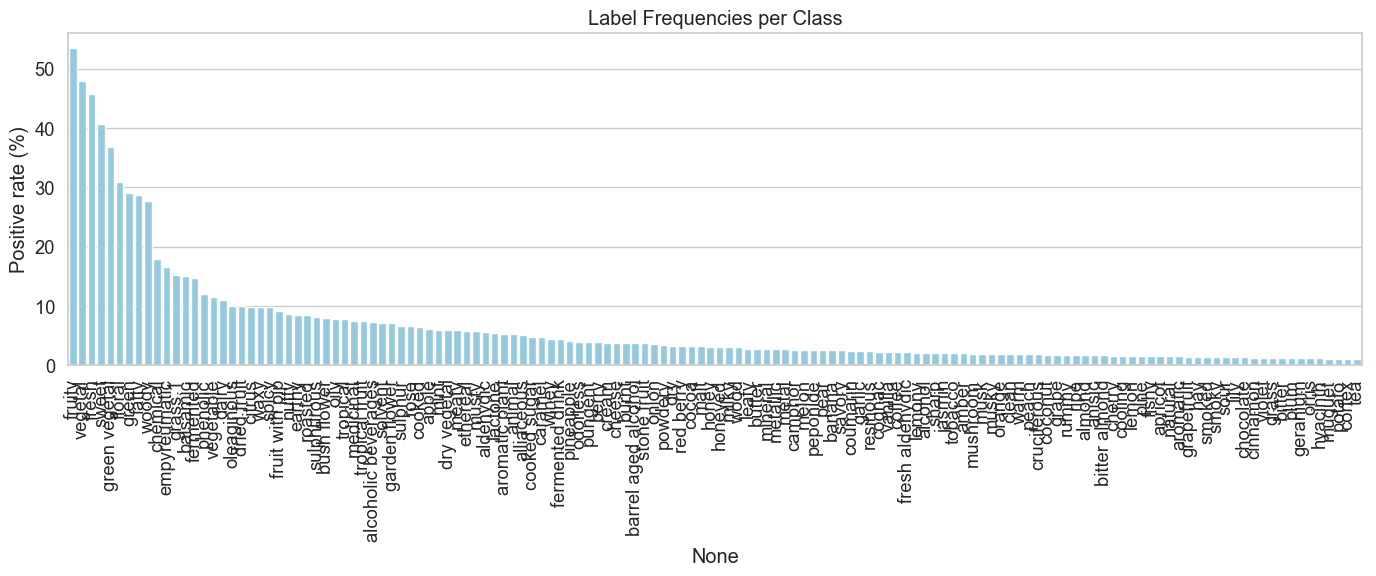

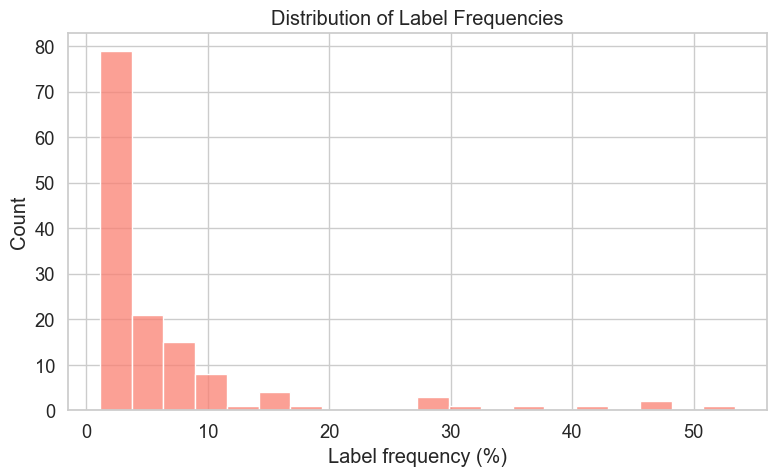


--- Label Cardinality & Density ---
Label cardinality (avg labels per sample): 8.98
Label density: 0.0651


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Config for plots
sns.set(style='whitegrid', font_scale=1.2)

# === Load your data ===
# Adjust filename as needed
df = pd.read_csv(r"C:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\data\Data_Sampling\FrequentOdor_extraction\(sat)mapped+unmapped_odors_openPOM_Top138.csv")

# The labels are from the 3rd column onward (0-based index: 2)
labels = df.iloc[:, 2:]

print(f"Loaded dataset with shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of labels: {labels.shape[1]}")

# Convert to numpy array for computation
y = labels.values  # shape: (n_samples, n_labels)

# === Label frequency per class ===
freqs = y.mean(axis=0)  # proportion of positives per class
freqs_pct = freqs * 100  # in percent

print("\n--- Label Frequency Statistics ---")
print(f"Min frequency: {freqs_pct.min():.2f}%")
print(f"Max frequency: {freqs_pct.max():.2f}%")
print(f"Mean frequency: {freqs_pct.mean():.2f}%")
print(f"Median frequency: {np.median(freqs_pct):.2f}%")
print(f"Std. dev of frequencies: {freqs_pct.std():.2f}%")

# Optional: show most and least frequent labels
most_frequent_idx = np.argmax(freqs)
least_frequent_idx = np.argmin(freqs)

print(f"Most frequent label: {labels.columns[most_frequent_idx]} ({freqs_pct[most_frequent_idx]:.2f}%)")
print(f"Least frequent label: {labels.columns[least_frequent_idx]} ({freqs_pct[least_frequent_idx]:.2f}%)")

# === Plot label frequencies ===
plt.figure(figsize=(14, 6))
sns.barplot(x=labels.columns, y=freqs_pct, color='skyblue')
plt.xticks(rotation=90)
plt.ylabel("Positive rate (%)")
plt.title("Label Frequencies per Class")
plt.tight_layout()
plt.show()

# Alternatively: histogram of frequencies
plt.figure(figsize=(8, 5))
sns.histplot(freqs_pct, bins=20, kde=False, color='salmon')
plt.xlabel("Label frequency (%)")
plt.title("Distribution of Label Frequencies")
plt.tight_layout()
plt.show()

# === Label cardinality & density ===
n_samples, n_labels = y.shape

cardinality = y.sum(axis=1).mean()
density = cardinality / n_labels

print("\n--- Label Cardinality & Density ---")
print(f"Label cardinality (avg labels per sample): {cardinality:.2f}")
print(f"Label density: {density:.4f}")
